# Comparison between the different altimetric product
- surface + 15m depth
- $\Delta T$<3h
- Gradient compute from the duacs speed


In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50, images_dir, U2, err_acc
from diagnosis import update_dict, dataset_coloc_combs, dataset_coloc_combs, prepared_drifters, prepared_wd, prepared_alti, compute_mean_square, compute_mean_square_groupby

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

In [2]:
dd = pd.read_csv(os.path.join(zarr_dir, 'coloc_files', 'alti', 'alticoloc_swot250m_general_12h_spectral_decomp_all_med_variational_10min_v0.csv')).set_index('row_number')
dd[dd.distance_to_coast>10e3]

,Unnamed: 0,pass_number,cycle_number,longitude,latitude,ancillary_surface_classification_flag,cross_track_distance,distance_to_coast,duacs_editing_flag,duacs_phase_screen,...,duacs_relative_vorticity,duacs_speed_meridional,duacs_speed_meridional_abs,duacs_speed_zonal,duacs_speed_zonal_abs,duacs_strain,duacs_xcal,sig0_karin_2,phi,swh_model
row_number,,,,,,,,,,,,,,,,,,,,,
54091,62,3,500,5.026858,43.237474,0.0,-31724.339406,10000.000000,0.0,-0.004505,...,-14.054136,-0.309494,-0.330182,-0.703771,-0.732461,0.000985,1.327443,25.701950,0.243507,0.564103
54094,65,3,500,5.031040,43.232168,0.0,-31248.105429,10033.346669,0.0,-0.004404,...,2.087065,-0.468178,-0.489398,-0.177664,-0.207932,0.000892,1.307830,25.512154,0.242636,0.567008
54095,66,3,500,5.032449,43.230324,0.0,-31061.197564,10490.124003,0.0,-0.004395,...,-2.328528,-0.298335,-0.319787,-0.223116,-0.253820,0.000722,1.300206,25.577101,0.243609,0.567755
54096,67,3,500,5.033875,43.228447,0.0,-30935.217914,10940.369859,0.0,-0.004374,...,-2.574502,-0.243576,-0.265218,-0.336157,-0.367394,0.000447,1.295031,25.420939,0.243380,0.568259
54097,68,3,500,5.035324,43.226539,0.0,-30750.000942,11000.000000,0.0,-0.004300,...,-2.194303,-0.355904,-0.377804,-0.306774,-0.338674,0.000496,1.287400,24.664105,0.243788,0.569007
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
362841,4559,16,561,1.100048,40.530493,0.0,58150.946970,27000.000000,0.0,0.000460,...,0.858639,-0.125499,-0.171832,-0.065557,-0.065899,0.000560,-0.275185,24.791088,2.901136,0.622468
362842,4560,16,561,1.101715,40.530875,0.0,57981.526423,27000.000000,0.0,0.000407,...,-0.489114,-0.124127,-0.170691,-0.043663,-0.044106,0.000400,-0.274304,24.815027,2.901059,0.622501
362843,4561,16,561,1.103356,40.531273,0.0,57845.178782,27000.000000,0.0,0.000400,...,-1.351426,-0.144138,-0.190931,-0.055393,-0.055885,0.000412,-0.273595,24.994555,2.900332,0.622263


# Generate

In [3]:
dt = 3

In [7]:
# SURFACE
base_dic = dict(dt='12h', 
        drifter_preprocess = '',
        drifter_preprocess_param='',
        alti_product_key='swot250m',
        alti_diff_method = 'fromduacsv',
        alti_diff_method_param = '',
        ggd_var = 'fromduacsv',
        wd_product_key = 'era5', 
        wd_model ='rio', 
        wd_depth = '0')


comb_list = [ 
    update_dict(base_dic, {'alti_diff_method':'diff_only', 'ggd_var':'etac'}),
    update_dict(base_dic, {'alti_diff_method':'diff_only', 'ggd_var':'etaf'}), 
    base_dic, 
    update_dict(base_dic, {'alti_product_key':'swot2km','alti_diff_method':'diff_only', 'ggd_var':'etac'}),
    update_dict(base_dic, {'alti_product_key':'swot2km','alti_diff_method':'diff_only', 'ggd_var':'etaf'}),
    update_dict(base_dic, {'alti_product_key':'swot2km'}), 
    update_dict(base_dic, {'alti_product_key':'L4_noswot_regional'}),
    update_dict(base_dic, {'alti_product_key':'L4_noswot_global'}),
    update_dict(base_dic, {'alti_product_key':'L4_withnadirswot'}),
]

l = [
    'L3-250m-etac',
    'L3-250m-etaf',
    'L3-250m',
    'L3-2km-etac',
    'L3-2km-etaf',
    'L3-2km',
    'L4-no-SWOT-regional',
    'L4-no-SWOT-global',
    'L4-SWOT-nadir']


ds0 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)
ds0['comb'] = ds0['id_comb']
ds0['id_comb'] = ('id_comb',l)
distance_to_coast = ds0.distance_to_coast.sel(id_comb = 'L3-250m-etaf')
ds0['distance_to_coast'] = ('row_number', distance_to_coast.values)

#DEPTH 15M
base_dic = dict(dt='12h', 
            drifter_preprocess = '',
            drifter_preprocess_param='',
            alti_product_key='swot250m',
            alti_diff_method = 'fromduacsv',
            alti_diff_method_param = '',
            ggd_var = 'fromduacsv',
            wd_product_key = 'era5', 
            wd_model ='rio', 
            wd_depth = '15')
comb_list = [ 
    update_dict(base_dic, {'alti_diff_method':'diff_only', 'ggd_var':'etac'}),
    update_dict(base_dic, {'alti_diff_method':'diff_only', 'ggd_var':'etaf'}), 
    base_dic, 
    update_dict(base_dic, {'alti_product_key':'swot2km','alti_diff_method':'diff_only', 'ggd_var':'etac'}),
    update_dict(base_dic, {'alti_product_key':'swot2km','alti_diff_method':'diff_only', 'ggd_var':'etaf'}), 
    update_dict(base_dic, {'alti_product_key':'swot2km'}), 
    update_dict(base_dic, {'alti_product_key':'L4_noswot_regional'}),
    update_dict(base_dic, {'alti_product_key':'L4_noswot_global'}),
    update_dict(base_dic, {'alti_product_key':'L4_withnadirswot'}),
]

ds15 = dataset_coloc_combs(comb_list, nearest =False, remove_id_outliers = True)
ds15['comb'] = ds15['id_comb']
ds15['id_comb'] = ('id_comb',l)
distance_to_coast = ds15.distance_to_coast.sel(id_comb = 'L3-250m-etaf')
ds15['distance_to_coast'] = ('row_number', distance_to_coast.values)

DS = xr.concat([ds0.where(ds0.depth==0, drop=True), ds15.where(ds15.depth==15, drop=True)], dim='row_number')
DS = DS.where(DS.time_to_swot/pd.Timedelta('1h')<dt).dropna('row_number')

# Closure figs
ds = compute_mean_square(DS)/U2
df = ds.to_dataframe()
df = df.reset_index().rename(columns={'id_comb':'Altimetric product'}).set_index('Altimetric product')


358076
12h_spectral_decomp_all_med_variational_10min_v0____swot250m_diff_only__etac__era5_rio0
357404
12h_spectral_decomp_all_med_variational_10min_v0____swot250m_diff_only__etaf__era5_rio0
349647
12h_spectral_decomp_all_med_variational_10min_v0____swot250m_fromduacsv__fromduacsv__era5_rio0
303001
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_diff_only__etac__era5_rio0
300813
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_diff_only__etaf__era5_rio0
307771
12h_spectral_decomp_all_med_variational_10min_v0____swot2km_fromduacsv__fromduacsv__era5_rio0
only 'fromduacsv' method is available for L4
365891
12h_spectral_decomp_all_med_variational_10min_v0____L4_noswot_regional_fromduacsv__fromduacsv__era5_rio0
only 'fromduacsv' method is available for L4
368591
12h_spectral_decomp_all_med_variational_10min_v0____L4_noswot_global_fromduacsv__fromduacsv__era5_rio0
only 'fromduacsv' method is available for L4
373036
12h_spectral_decomp_all_med_variational_10min_v0____L4_

In [9]:
DS = DS.where(DS.distance_to_coast>10e3, drop=True)

In [10]:
# Closure figs
ds = compute_mean_square(DS)/U2
df = ds.to_dataframe()
df = df.reset_index().rename(columns={'id_comb':'Altimetric product'}).set_index('Altimetric product')

In [11]:
df[['B_ggd', 'E_ggd']]

,B_ggd,E_ggd
Altimetric product,,
L3-250m-etac,2.355918,2978.753526
L3-250m-etaf,2.709304,7.150720
L3-250m,2.333912,3.869407
L3-2km-etac,2.749418,7.848508
L3-2km-etaf,2.445880,2.703502
L3-2km,2.104076,1.046414
L4-no-SWOT-regional,0.889798,0.050954
L4-no-SWOT-global,0.771473,-0.031976
L4-SWOT-nadir,1.026870,0.034577


# Closure figs
print(DSS.sizes['row_number'])
for c in df.index :
    plt.rcParams["axes.edgecolor"] = "w"
    fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(20,5), frameon=False)
    synthetic_figure(df.loc[c], axs[0], dir='e', xlim=[-1, 10])
    synthetic_figure(df.loc[c], axs[1], dir='n', xlim=[-1, 10])
    fig.suptitle(c)
    fig.tight_layout()
    fig.savefig(os.path.join(images_dir, 'closure_figs', '15m_' + c + '.png'))


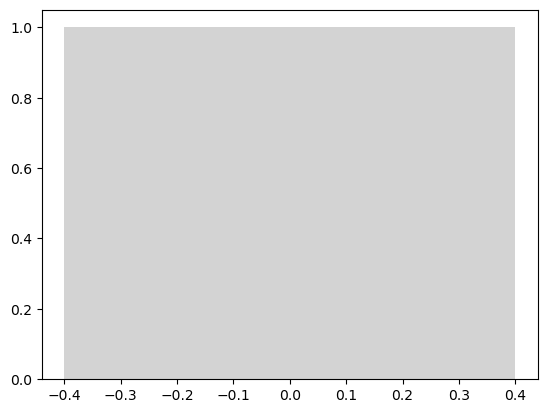

In [12]:
fig, ax=plt.subplots()
#ax.bar(0,1, color=c0['acc'], label='Lagrangian acceleration')
#ax.bar(0,1, color=c0['cor'], label='Coriolis acceleration')
ax.bar(0,1, color=c0['ggd'], label='Balanced signal contribution')
#ax.bar(0,1, color=c0['wd'], label='Wind term')
ax.bar(0,1, color='lightgrey', label='Residual contribution')

handles, labels = ax.get_legend_handles_labels()


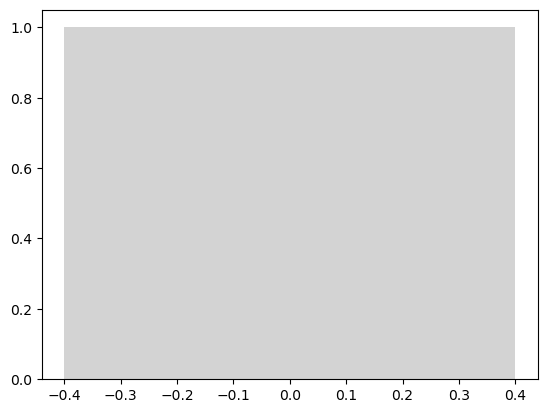

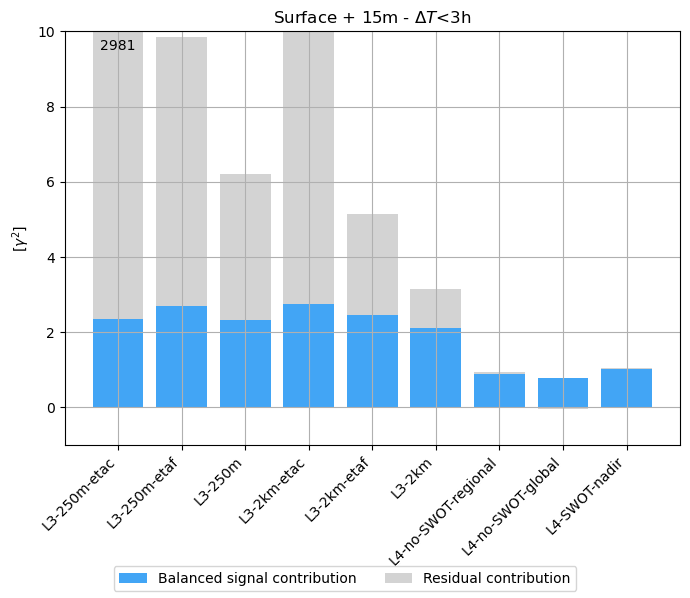

In [13]:
fig, ax=plt.subplots()
#ax.bar(0,1, color=c0['acc'], label='Lagrangian acceleration')
#ax.bar(0,1, color=c0['cor'], label='Coriolis acceleration')
ax.bar(0,1, color=c0['ggd'], label='Balanced signal contribution')
#ax.bar(0,1, color=c0['wd'], label='Wind term')
ax.bar(0,1, color='lightgrey', label='Residual contribution')

handles, labels = ax.get_legend_handles_labels()


# Alti comparison
fig, ax = plt.subplots(frameon=False, figsize=(7, 6))
plt.rcParams["axes.edgecolor"] = "k"
for i in range(len(df)):
    df_ = df.iloc[i]
    # residual contribution
    plt.rcParams["hatch.linewidth"] = 6
    if df_.E_ggd>0: ax.bar(i, df_.E_ggd, bottom = df_.B_ggd,color = 'lightgrey')
    else: ax.bar(i, df_.E_ggd,color = 'lightgrey')
    ax.bar(i, df_.B_ggd,color = c0['ggd'])

    #plt.rcParams["hatch.color"] = c0['ggd']
    #ax.bar(i, df_.X_acc_ggd/2, color = c0['acc'], hatch="/", width=0.4, label = '')
    #ax.bar(i, df_.X_cor_ggd/2, color = c0['cor'], hatch="/", width=0.4)
    #ax.bar(i, df_.X_ggd_wd/2, color = c0['wd'], hatch="/", bottom = df_.X_cor_ggd/2, width=0.4)
    
ax.grid()
ax.set_ylabel(r'[$\gamma^2$]')
ax.set_xticks(ticks = np.arange(len(df)),labels = df.index, rotation = 45, ha='right' )
ax.set_title(rf'Surface + 15m - $\Delta T$<{dt}h')
ax.set_ylim(-1,10)
ax.annotate(f'{round(df.iloc[0].E_ggd+df.iloc[0].B_ggd)}', (0,9.5), ha='center')
fig.tight_layout(rect=[0, 0.02, 1, 1])
fig.legend(handles, labels, ncol=3, loc="lower center")
#fig.savefig(os.path.join(images_dir, 'alti_comparison', 'alti_comparison_surface_ggd.png'))


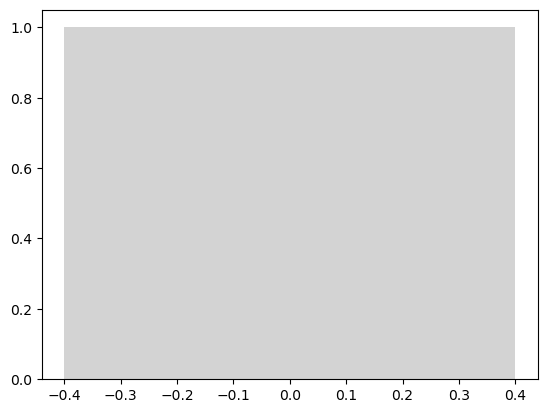

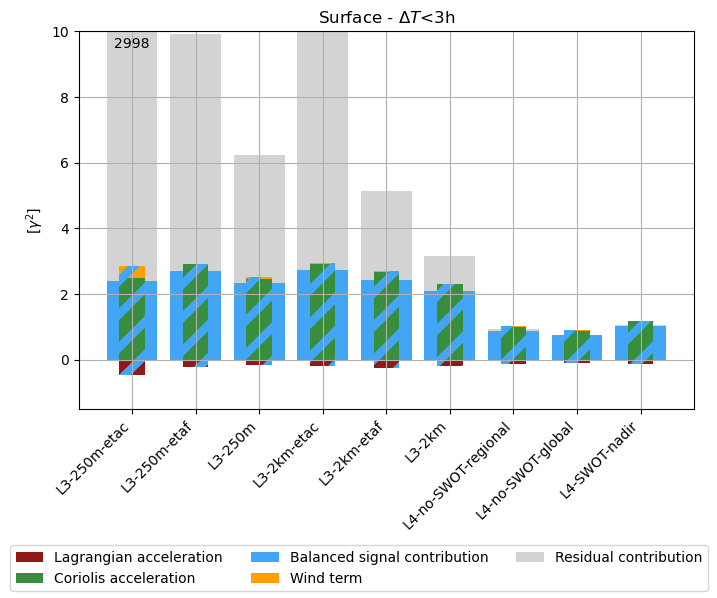

In [15]:
fig, ax=plt.subplots()
ax.bar(0,1, color=c0['acc'], label='Lagrangian acceleration')
ax.bar(0,1, color=c0['cor'], label='Coriolis acceleration')
ax.bar(0,1, color=c0['ggd'], label='Balanced signal contribution')
ax.bar(0,1, color=c0['wd'], label='Wind term')
ax.bar(0,1, color='lightgrey', label='Residual contribution')

handles, labels = ax.get_legend_handles_labels()


# Alti comparison
fig, ax = plt.subplots(frameon=False, figsize=(7, 6))
plt.rcParams["axes.edgecolor"] = "k"
for i in range(len(df)):
    df_ = df.iloc[i]
    # residual contribution
    plt.rcParams["hatch.linewidth"] = 6
    if df_.E_ggd>0: ax.bar(i, df_.E_ggd, bottom = df_.B_ggd,color = 'lightgrey')
    else: ax.bar(i, df_.E_ggd,color = 'lightgrey')
    ax.bar(i, df_.B_ggd,color = c0['ggd'])

    plt.rcParams["hatch.color"] = c0['ggd']
    ax.bar(i, df_.X_acc_ggd/2, color = c0['acc'], hatch="/", width=0.4, label = '')
    ax.bar(i, df_.X_cor_ggd/2, color = c0['cor'], hatch="/", width=0.4)
    ax.bar(i, df_.X_ggd_wd/2, color = c0['wd'], hatch="/", bottom = df_.X_cor_ggd/2, width=0.4)
    
ax.grid()
ax.set_ylabel(r'[$\gamma^2$]')
ax.set_xticks(ticks = np.arange(len(df)),labels = df.index, rotation = 45,ha='right' )
ax.set_title(rf'Surface - $\Delta T$<{dt}h')
ax.set_ylim(-1.5,10)
ax.annotate(f'{round(df.iloc[0].E_ggd+df.iloc[0].B_ggd)}', (0,9.5), ha='center')
fig.tight_layout(rect=[0, 0.08, 1, 1])
fig.legend(handles, labels, ncol=3, loc="lower center")
#fig.savefig(os.path.join(images_dir, 'alti_comparison', 'alti_comparison_surface_ggd.png'))


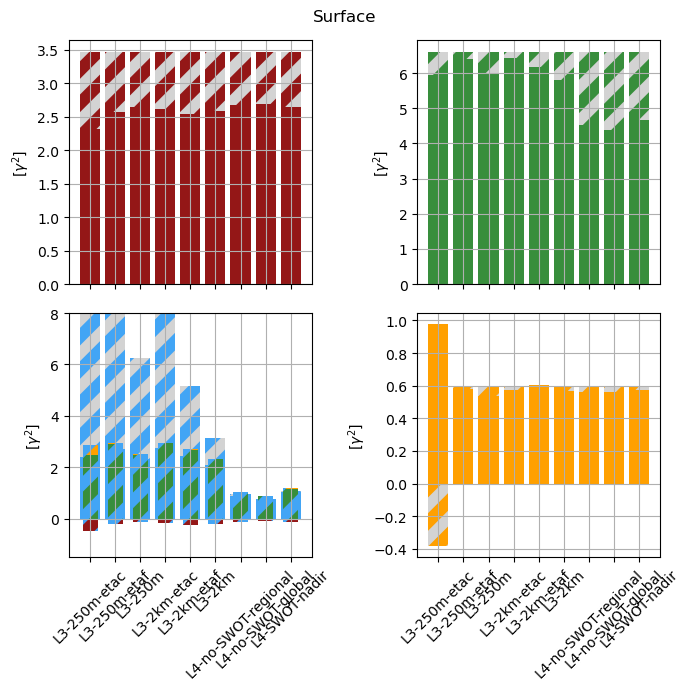

In [17]:
# Alti comparison
vars = ['acc', 'cor', 'ggd','wd']
plt.rcParams["axes.edgecolor"] = "k"
fig, axs = plt.subplots(2, 2, figsize = (7, 7), frameon=False, sharex=True)
axs = axs.flatten()
for i in range(len(df)):
    df_ = df.iloc[i]
    plt.rcParams["hatch.linewidth"] = 8
    for j in range(4):
        ax=axs[j]
        # residual contribution
        plt.rcParams["hatch.color"] = "lightgrey"
        if df_['E_'+vars[j]]>0: ax.bar(i, df_['E_'+vars[j]], bottom = df_['B_'+vars[j]],color = c0[vars[j]], hatch="/")
        else: ax.bar(i, df_['E_'+vars[j]], color = c0[vars[j]], hatch="/")
        ax.bar(i, df_['B_'+vars[j]],color = c0[vars[j]])


    ax = axs[2]
    plt.rcParams["hatch.color"] = c0['ggd']
    ax.bar(i, df_.X_acc_ggd/2, color = c0['acc'], hatch="/", width=0.6)
    ax.bar(i, df_.X_cor_ggd/2, color = c0['cor'], hatch="/", width=0.6)
    ax.bar(i, df_.X_ggd_wd/2, color = c0['wd'], hatch="/", bottom = df_.X_cor_ggd/2, width=0.6)

for ax in axs :    
    ax.grid()
    ax.set_ylabel(r'[$\gamma^2$]')
    ax.set_xticks(ticks = np.arange(len(df)),labels = df.index, rotation = 45 )

axs[2].set_ylim(-1.5,8)
fig.suptitle('Surface')
fig.tight_layout()
#fig.savefig(os.path.join(images_dir, 'alti_comparison', 'alti_comparison_surface_all.png'))


In [17]:
ds_ = ds0.sel( id_comb = 'L3-250m-etaf')
ds_

<xarray.Dataset> Size: 126MB
Dimensions:            (row_number: 373554)
Coordinates: (12/13)
    datetime           (row_number) datetime64[ns] 3MB 2023-04-01T11:50:00 .....
    longitude          (row_number) float64 3MB 4.812 4.812 ... 2.415 2.414
    latitude           (row_number) float64 3MB 42.22 42.22 ... 39.79 39.79
    pass_number        (row_number) float64 3MB 3.0 3.0 3.0 ... 16.0 16.0 16.0
    time_to_swot       (row_number) timedelta64[ns] 3MB 11:52:32.696536 ... 1...
    cycle_number       (row_number) float64 3MB 478.0 478.0 ... 577.0 577.0
    ...                 ...
    drifter_type       (row_number) object 3MB 'SVP' 'SVP' 'SVP' ... 'SVP' 'SVP'
    depth              (row_number) float64 3MB 15.0 15.0 15.0 ... 15.0 15.0
    phi                (row_number) float64 3MB 0.2354 0.237 ... 2.917 2.917
    distance_to_coast  (row_number) float64 3MB 1.14e+05 1.139e+05 ... 1.395e+04
  * row_number         (row_number) int64 3MB 0 1 2 3 ... 376720 376721 376722
    id_comb            <U19 76B 'L3-250m-etaf'
Data variables: (12/31)
    sume               (row_number) float64 3MB -1.804e-05 ... -4.943e-06
    acce               (row_number) float64 3MB 6.386e-06 ... -1.995e-06
    exce_acc           (row_number) float64 3MB -2.442e-05 ... -2.948e-06
    core               (row_number) float64 3MB -1.001e-05 ... -1.024e-05
    exce_cor           (row_number) float64 3MB -8.022e-06 ... 5.3e-06
    ggde               (row_number) float64 3MB 1.129e-05 9.31e-06 ... 6.451e-06
    ...                 ...
    prodn_acc_ggd      (row_number) float64 3MB -3.574e-10 ... -3.565e-10
    prodn_acc_wd       (row_number) float64 3MB 9.676e-11 ... 4.653e-11
    prodn_cor_ggd      (row_number) float64 3MB 1.823e-10 ... 5.604e-10
    prodn_cor_wd       (row_number) float64 3MB -4.934e-11 ... -7.314e-11
    prodn_ggd_wd       (row_number) float64 3MB -2.359e-10 ... -2.511e-10
    comb               <U104 416B '12h_spectral_decomp_all_med_variational_10...

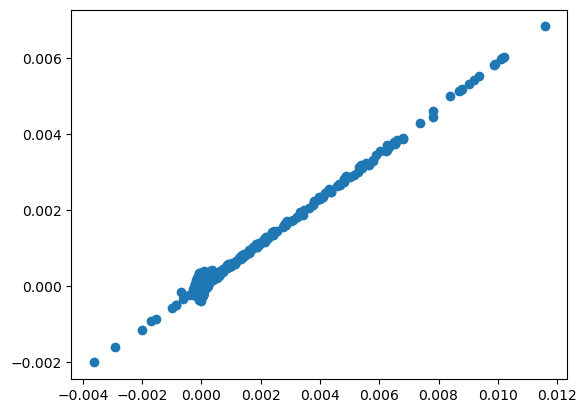

In [18]:
plt.scatter(ds_.ggde, ds_.ggdn)

In [25]:
df_ = ds_.to_dataframe()

In [58]:
df_.ggde.quantile(0.999)
#df_.ggde.max()

0.00015104925161420267

In [57]:
f = glob(os.path.join(zarr_dir, 'before_coloc','preprocessed_swot','swot250m','diff_only', '*'))

In [40]:
f

['/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC/before_coloc/preprocessed_swot/swot250m/diff_only/3_490.nc',
 '/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC/before_coloc/preprocessed_swot/swot250m/diff_only/16_552.nc',
 '/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC/before_coloc/preprocessed_swot/swot250m/diff_only/3_560.nc',
 '/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC/before_coloc/preprocessed_swot/swot250m/diff_only/3_518.nc',
 '/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC/before_coloc/preprocessed_swot/swot250m/diff_only/3_504.nc',
 '/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC/before_coloc/preprocessed_swot/swot250m/diff_only/3_529.nc',
 '/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC/before_coloc/preprocessed_swot/swot250m/diff_only/16_571.nc',
 '/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC/before_coloc/preprocessed_swot/swot250m/diff_only/3_489.nc',
 '/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC/before_coloc/preprocesse

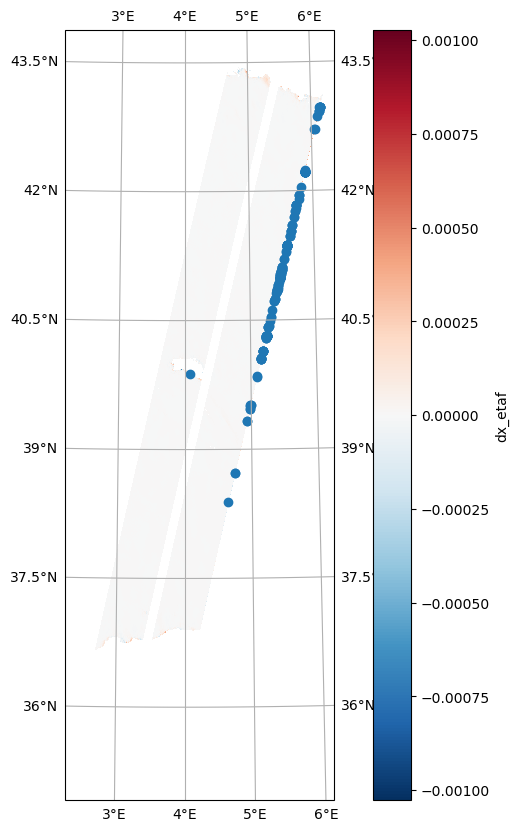

In [61]:
df__ = df_[df_.ggde>3e-4]
fig = plt.figure(figsize=(10,10))
fig.patch.set_facecolor('white')#no transparancy in png
ax = fig.add_subplot(111, projection=ccrs.Orthographic(4,40))

dss = xr.open_dataset(f[10])
dss.dx_etaf.plot(x='longitude', y='latitude', transform=crs)

ax.scatter(df__.longitude, df__.latitude, transform = crs)
gl = ax.gridlines(draw_labels=True,)


In [62]:
dss

<xarray.Dataset> Size: 242MB
Dimensions:    (num_lines: 4161, num_pixels: 519)
Coordinates:
    longitude  (num_lines, num_pixels) float64 17MB ...
    latitude   (num_lines, num_pixels) float64 17MB ...
Dimensions without coordinates: num_lines, num_pixels
Data variables:
    etaf       (num_lines, num_pixels) float64 17MB ...
    dx_etaf    (num_lines, num_pixels) float64 17MB ...
    dy_etaf    (num_lines, num_pixels) float64 17MB ...
    dxx_etaf   (num_lines, num_pixels) float64 17MB ...
    dyy_etaf   (num_lines, num_pixels) float64 17MB ...
    dxy_etaf   (num_lines, num_pixels) float64 17MB ...
    etac       (num_lines, num_pixels) float64 17MB ...
    dx_etac    (num_lines, num_pixels) float64 17MB ...
    dy_etac    (num_lines, num_pixels) float64 17MB ...
    dxx_etac   (num_lines, num_pixels) float64 17MB ...
    dyy_etac   (num_lines, num_pixels) float64 17MB ...
    dxy_etac   (num_lines, num_pixels) float64 17MB ...